In [1]:
import pandas as pd

In [7]:
cv=pd.read_csv("C:/Users/Lenovo/OneDrive/Desktop/dataset/archive (1)/beginner_datasets/owid-covid-data.csv")

In [10]:
# dimensioni
print(cv.shape)
print(cv.info())
print(cv.dtypes)

# mancanti
print(cv.isnull().sum())

print(cv.describe())
print(cv.head())

(429435, 67)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-nu

In [25]:
# valori unici di location con continent nullo
print(cv[cv['continent'].isna()]['location'].unique())

# differenza tra new_cases e total_cases
print(cv[['date','location','new_cases','total_cases']][cv['total_cases'] >1].head(10))

['Africa' 'Asia' 'Europe' 'European Union (27)' 'High-income countries'
 'Low-income countries' 'Lower-middle-income countries' 'North America'
 'Oceania' 'South America' 'Upper-middle-income countries' 'World']
          date     location  new_cases  total_cases
70  2020-03-15  Afghanistan        6.0          7.0
71  2020-03-16  Afghanistan        0.0          7.0
72  2020-03-17  Afghanistan        0.0          7.0
73  2020-03-18  Afghanistan        0.0          7.0
74  2020-03-19  Afghanistan        0.0          7.0
75  2020-03-20  Afghanistan        0.0          7.0
76  2020-03-21  Afghanistan        0.0          7.0
77  2020-03-22  Afghanistan       17.0         24.0
78  2020-03-23  Afghanistan        0.0         24.0
79  2020-03-24  Afghanistan        0.0         24.0


In [11]:
# casi totali per continente
cv_continenti = cv[cv['continent'].notna()]

casi_continente = cv_continenti.groupby('continent')['total_cases'].max()
print(casi_continente)

# percentuale sul totale mondiale
percentuale = (casi_continente / casi_continente.sum() * 100).round(2)
print(percentuale)

continent
Africa             4072765.0
Asia              99373219.0
Europe            38997490.0
North America    103436829.0
Oceania           11861161.0
South America     37511921.0
Name: total_cases, dtype: float64
continent
Africa            1.38
Asia             33.66
Europe           13.21
North America    35.03
Oceania           4.02
South America    12.70
Name: total_cases, dtype: float64


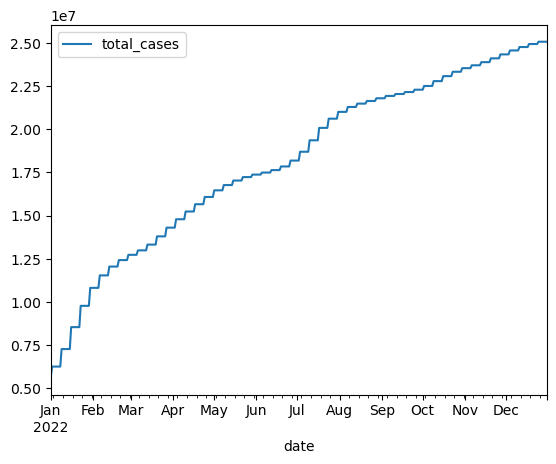

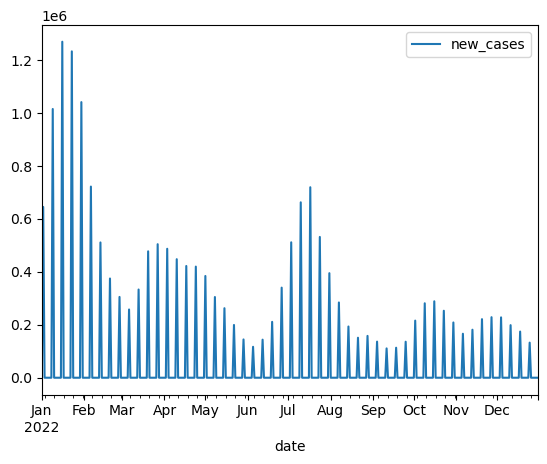

In [18]:
import matplotlib.pyplot as plt

italia = cv[cv['location'] == 'Italy']
italia = italia[italia['date'].str.startswith('2022')]
italia = italia[italia['new_cases'].notna()]
italia['date'] = pd.to_datetime(italia['date'])

italia.plot(x='date', y='total_cases')
plt.show()

italia.plot(x='date', y='new_cases')
plt.show()

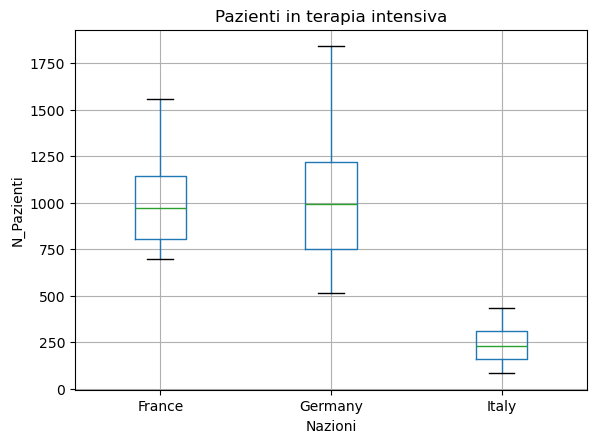

In [32]:
# filtro i tre paesi
paesi = cv[cv['location'] .isin (['Italy','Germany','France'])]
# filtro il periodo maggio 2022 - aprile 2023
paesi = paesi[(paesi['date'] >= '2022-05-01') & (paesi['date'] <= '2023-04-30')]
# boxplot
paesi.boxplot(column='icu_patients', by='location')
plt.title('Pazienti in terapia intensiva')
plt.suptitle('')
plt.xlabel('Nazioni')
plt.ylabel('N_Pazienti')
plt.show()

In [28]:
"""
Nel periodo maggio 2022 - aprile 2023, Francia e Germania hanno avuto 
un numero di pazienti in terapia intensiva significativamente più alto 
rispetto all'Italia, con mediane intorno a 1000 pazienti contro circa 250.
La Germania mostra inoltre una maggiore variabilità, con valori fino a quasi 1900.
"""

location
France     6008717.0
Germany          0.0
Italy      4419950.0
Spain      2411706.0
Name: hosp_patients, dtype: float64


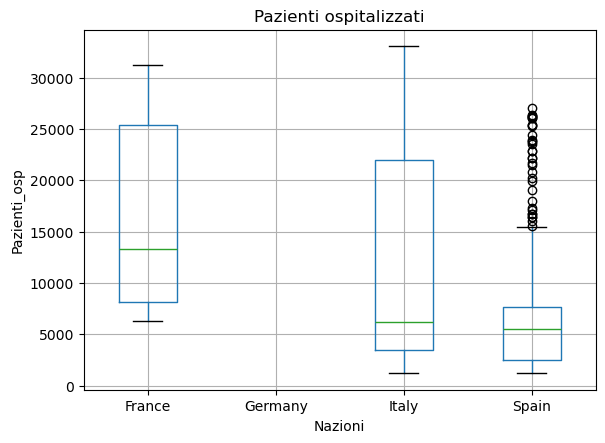

In [37]:
#presentazione numerica
paesi = cv[cv['location'] .isin (['Italy','Germany','France','Spain'])]
paesi = paesi[(paesi['date'] >= '2021-01-01') & (paesi['date'] <= '2021-12-31')]
pazienti_totali = paesi.groupby('location')['hosp_patients'].sum()
print(pazienti_totali)

#presentazione grafica
paesi.boxplot(column='hosp_patients', by='location')
plt.title('Pazienti ospitalizzati')
plt.suptitle('')
plt.xlabel('Nazioni')
plt.ylabel('Pazienti_osp')
plt.show()

In [ ]:
"""
La Germania non ha dati disponibili per il 2021.
Non conviene sostituire i valori mancanti con la media perché 
le ospedalizzazioni variano molto nel tempo e quindi mettendo la media su tutti i valori mancanti darebbe un numero FALSO che non rappresenterebbe la realtà.
"""